<a href="https://colab.research.google.com/github/hadiasohail793/SkinCancerClassifier/blob/main/heart_disease_prediction_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# Fetch UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Separate features and target
X = heart_disease.data.features
y = heart_disease.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [3]:
# Check dataset information
print("Dataset Information:")
print(X.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB
None


In [4]:
# Display all feature names
print("Feature Names:")
print(X.columns.tolist())

Feature Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [5]:
# Display first 5 rows
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [6]:
# Display target values
print("Target values:")
print(y.head(10))

print("\nUnique target values:")
print(y.iloc[:, 0].unique())

print("\nTarget value counts:")
print(y.iloc[:, 0].value_counts())

Target values:
   num
0    0
1    2
2    1
3    0
4    0
5    0
6    3
7    0
8    2
9    1

Unique target values:
[0 2 1 3 4]

Target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [7]:
# Check missing values
print("Missing values in each feature:")
print(X.isnull().sum())

print("\nTotal missing values:")
print(X.isnull().sum().sum())

Missing values in each feature:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Total missing values:
6


In [8]:
# Check data types
print(X.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


In [9]:
# Statistical summary
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [10]:
# Convert target into binary classification
y = y.iloc[:, 0].apply(lambda x: 1 if x > 0 else 0)

# Check the result
print("Unique target values:", y.unique())
print("\nTarget distribution:")
print(y.value_counts())

Unique target values: [0 1]

Target distribution:
num
0    164
1    139
Name: count, dtype: int64


In [11]:
# Combine features and target into one DataFrame
df = X.copy()
df["target"] = y

# Display first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [14]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Fill missing values using median
X = X.fillna(X.median())

# Verify
print("Total missing values after cleaning:")
print(X.isnull().sum().sum())

Total missing values after cleaning:
0


In [15]:
print("Final dataset shape:")
print(X.shape)

print("\nFeature data types:")
print(X.dtypes)

print("\nTarget distribution:")
print(y.value_counts())

Final dataset shape:
(303, 13)

Feature data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [16]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

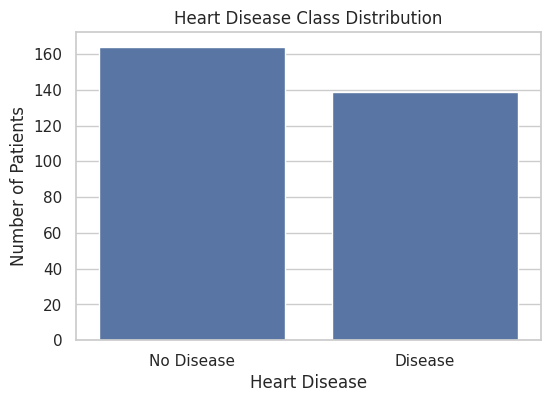

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

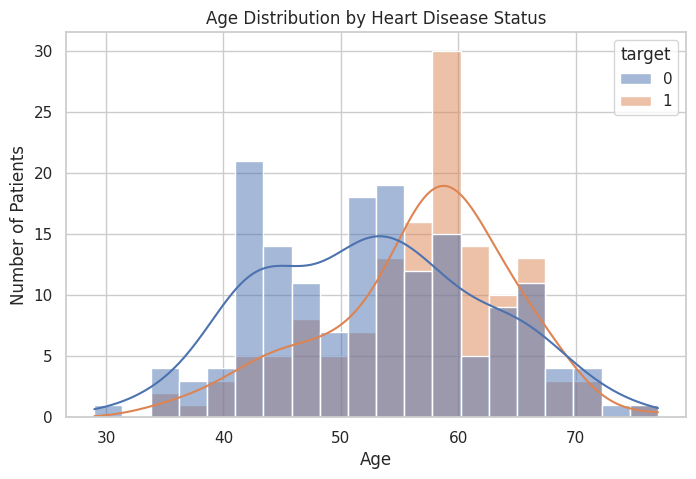

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="target",
    bins=20,
    kde=True
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

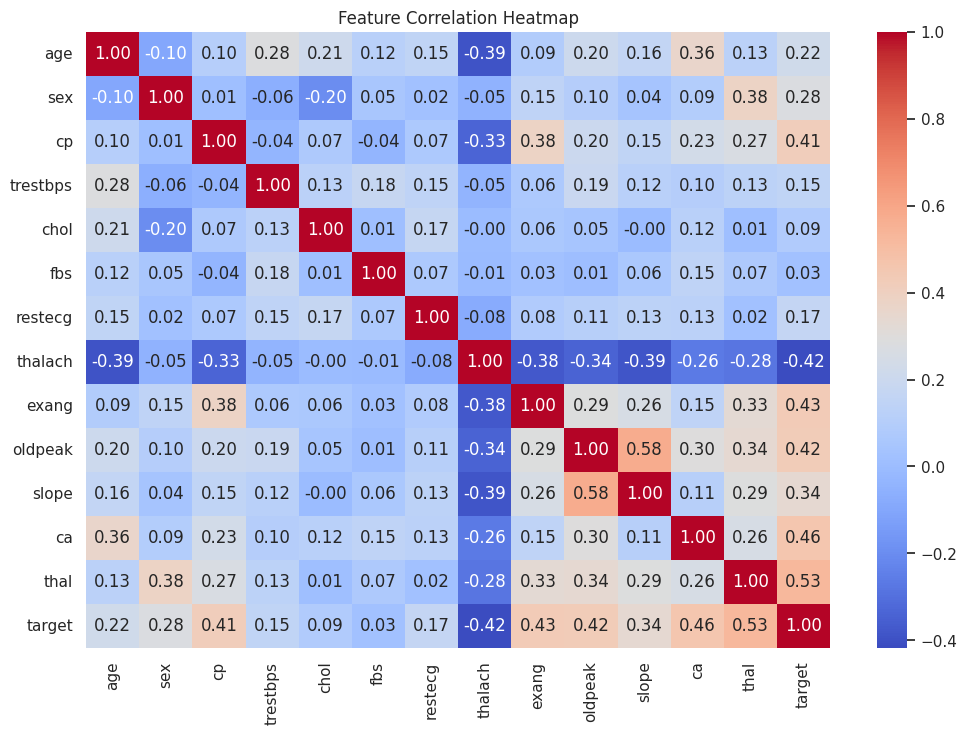

In [20]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

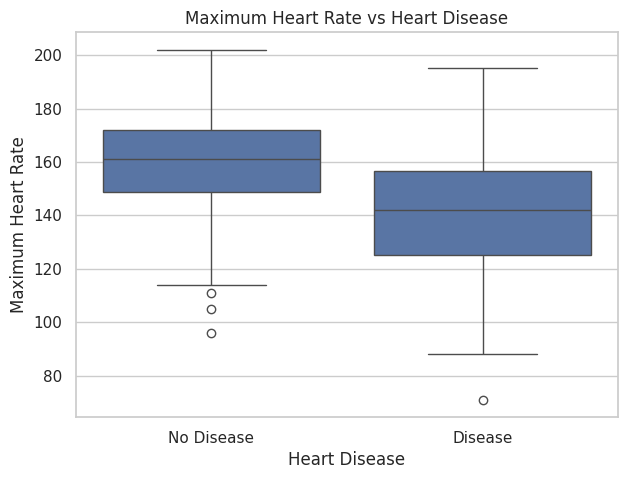

In [21]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="target",
    y="thalach"
)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

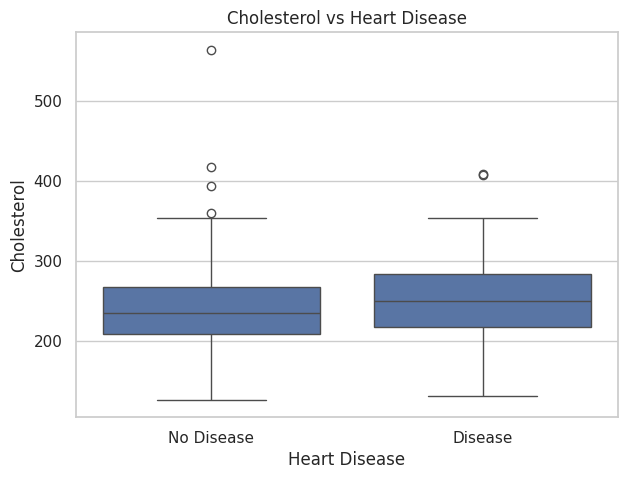

In [22]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="target",
    y="chol"
)

plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

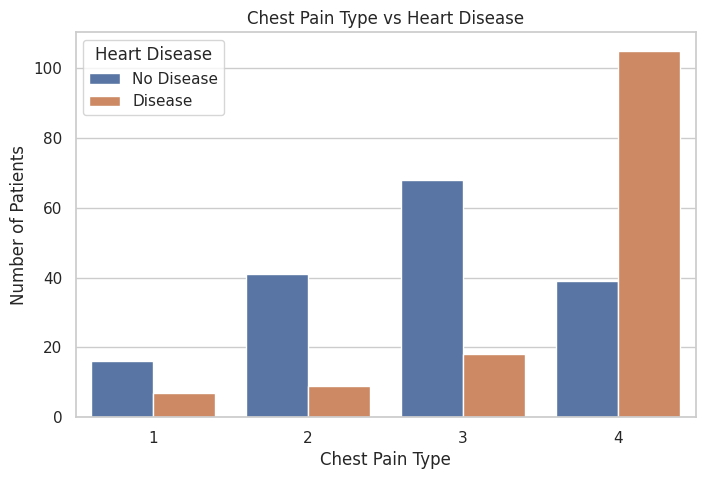

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="cp",
    hue="target"
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.legend(
    title="Heart Disease",
    labels=["No Disease", "Disease"]
)

plt.show()

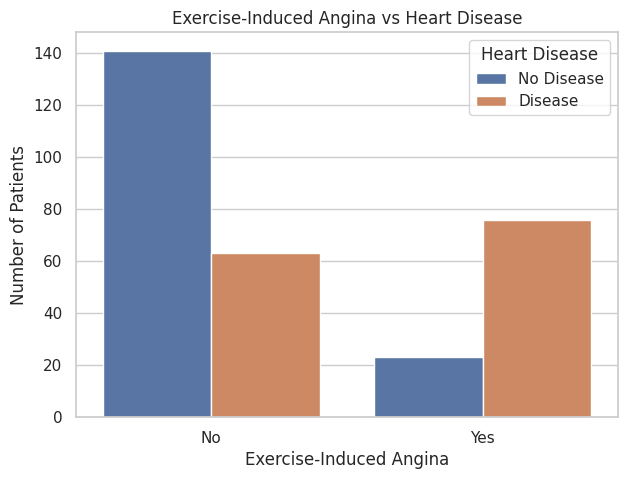

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="exang",
    hue="target"
)

plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

plt.xticks([0, 1], ["No", "Yes"])

plt.legend(
    title="Heart Disease",
    labels=["No Disease", "Disease"]
)

plt.show()

In [26]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Numerical features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (242, 13)
Testing set: (61, 13)


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [30]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (242, 13)
Processed training shape: (242, 28)
Original testing shape: (61, 13)
Processed testing shape: (61, 28)


In [31]:
print("Processed data type:", type(X_train_processed))
print("Processed training shape:", X_train_processed.shape)

Processed data type: <class 'numpy.ndarray'>
Processed training shape: (242, 28)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [33]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", SVC(kernel="rbf", probability=True, random_state=42))
    ]),

    "Naive Bayes": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", GaussianNB())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ])
}

print("Models created successfully:")
for name in models:
    print("-", name)

Models created successfully:
- Logistic Regression
- KNN
- SVM
- Naive Bayes
- Decision Tree


In [34]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
KNN trained successfully.
SVM trained successfully.
Naive Bayes trained successfully.
Decision Tree trained successfully.


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

print("Evaluation completed.")

Evaluation completed.


In [36]:
import pandas as pd

results_df = pd.DataFrame(results)

# Sort by F1 Score
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.885246,0.838710,0.928571,0.881356
1,SVM,0.885246,0.838710,0.928571,0.881356
2,KNN,0.885246,0.862069,0.892857,0.877193
3,Naive Bayes,0.721311,0.641026,0.892857,0.746269
4,Decision Tree,0.737705,0.676471,0.821429,0.741935


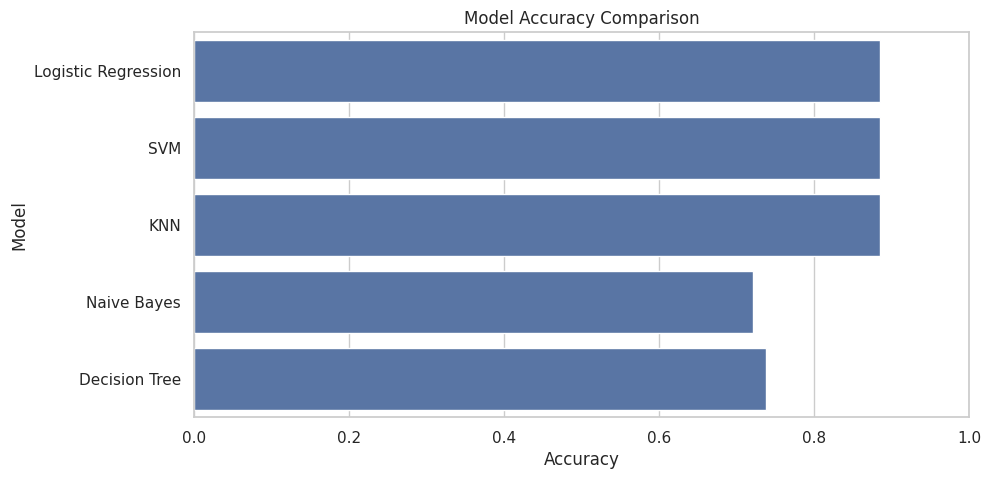

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)

plt.show()

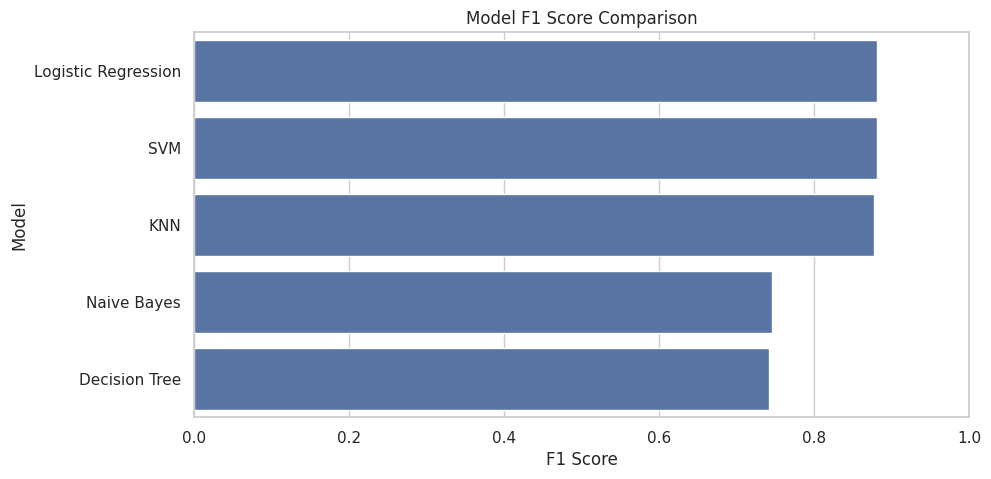

In [38]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model"
)

plt.title("Model F1 Score Comparison")
plt.xlim(0, 1)

plt.show()

In [39]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best F1 Score:", results_df.iloc[0]["F1 Score"])
print("Best Accuracy:", results_df.iloc[0]["Accuracy"])

Best Model: Logistic Regression
Best F1 Score: 0.8813559322033898
Best Accuracy: 0.8852459016393442


In [40]:
# Generate predictions using the best model
y_pred_best = best_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_best))

Predictions generated successfully.
Number of predictions: 61


In [41]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["No Disease", "Disease"]
    )
)

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[28  5]
 [ 2 26]]


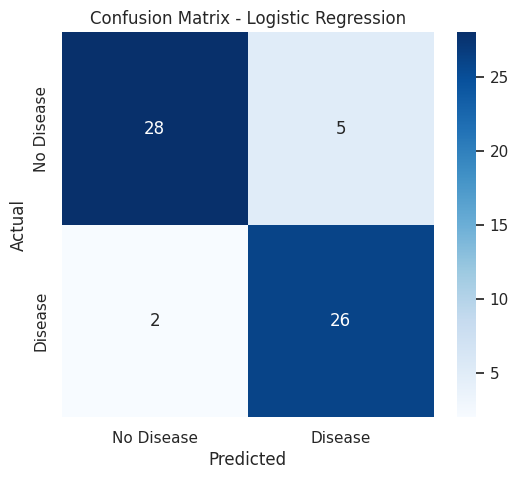

In [43]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability estimates
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9664502164502166


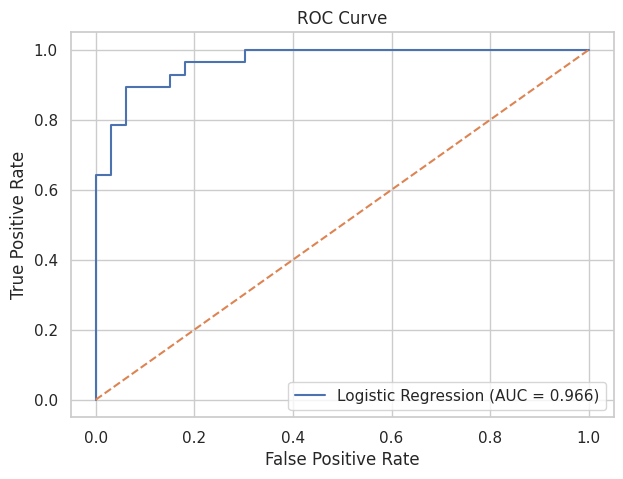

In [45]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [46]:
import joblib

In [47]:
model_filename = "heart_disease_model.pkl"

joblib.dump(best_model, model_filename)

print(f"Model saved successfully as: {model_filename}")

Model saved successfully as: heart_disease_model.pkl


In [48]:
import os

print("File exists:", os.path.exists(model_filename))
print("File size:", os.path.getsize(model_filename), "bytes")

File exists: True
File size: 4209 bytes


In [49]:
# Load the saved model
loaded_model = joblib.load(model_filename)

print("Model loaded successfully!")
print("Loaded model:", loaded_model)

Model loaded successfully!
Loaded model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


In [50]:
original_prediction = best_model.predict(X_test)
loaded_prediction = loaded_model.predict(X_test)

print(
    "Predictions identical:",
    (original_prediction == loaded_prediction).all()
)

Predictions identical: True


In [51]:
# Take one patient from the test dataset
sample_patient = X_test.iloc[[0]]

print("Sample patient:")
display(sample_patient)

Sample patient:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
219,59,1,4,138,271,0,2,182,0,0.0,1,0.0,3.0


In [52]:
prediction = loaded_model.predict(sample_patient)[0]

if prediction == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

Prediction: No Heart Disease


In [53]:
probability = loaded_model.predict_proba(sample_patient)[0]

print("Probability of No Disease:", probability[0])
print("Probability of Disease:", probability[1])

Probability of No Disease: 0.7907043310163464
Probability of Disease: 0.20929566898365365


In [64]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib


# ============================================================
# LOAD MODEL
# ============================================================

model = joblib.load("heart_disease_model.pkl")


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Heart Disease Prediction",
    page_icon="❤️",
    layout="wide"
)


# ============================================================
# HEADER
# ============================================================

st.title("❤️ Heart Disease Prediction System")

st.markdown(
    """
    ### Machine Learning-Based Cardiovascular Risk Prediction

    Enter the patient's clinical information below to obtain a
    prediction from the trained machine learning model.
    """
)

st.divider()


# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.header("ℹ️ About the Model")

    st.write(
        "This application uses a machine learning model trained "
        "on the UCI Heart Disease dataset."
    )

    st.write("**Features used:** 13")

    st.write(
        """
        **Models evaluated:**
        - Logistic Regression
        - K-Nearest Neighbors
        - Support Vector Machine
        - Naive Bayes
        - Decision Tree
        """
    )

    st.info(
        "The final model is selected based on its performance "
        "on the test dataset."
    )


# ============================================================
# PATIENT INFORMATION
# ============================================================

st.subheader("👤 Patient Clinical Information")

col1, col2 = st.columns(2)


# ============================================================
# LEFT COLUMN
# ============================================================

with col1:

    age = st.number_input(
        "Age (years)",
        min_value=1,
        max_value=120,
        value=50,
        step=1
    )


    sex = st.selectbox(
        "Sex",
        options=[0, 1],
        format_func=lambda x:
            "Female" if x == 0 else "Male"
    )


    cp = st.selectbox(
        "Chest Pain Type",
        options=[1, 2, 3, 4],
        format_func=lambda x: {
            1: "Typical Angina",
            2: "Atypical Angina",
            3: "Non-anginal Pain",
            4: "Asymptomatic"
        }[x]
    )


    trestbps = st.number_input(
        "Resting Blood Pressure (mm Hg)",
        min_value=50,
        max_value=250,
        value=120,
        step=1
    )


    chol = st.number_input(
        "Serum Cholesterol (mg/dl)",
        min_value=50,
        max_value=700,
        value=200,
        step=1
    )


    fbs = st.selectbox(
        "Fasting Blood Sugar > 120 mg/dl",
        options=[0, 1],
        format_func=lambda x:
            "No" if x == 0 else "Yes"
    )


    restecg = st.selectbox(
        "Resting ECG",
        options=[0, 1, 2],
        format_func=lambda x: {
            0: "Normal",
            1: "ST-T Wave Abnormality",
            2: "Left Ventricular Hypertrophy"
        }[x]
    )


# ============================================================
# RIGHT COLUMN
# ============================================================

with col2:

    thalach = st.number_input(
        "Maximum Heart Rate Achieved",
        min_value=50,
        max_value=250,
        value=150,
        step=1
    )


    exang = st.selectbox(
        "Exercise-Induced Angina",
        options=[0, 1],
        format_func=lambda x:
            "No" if x == 0 else "Yes"
    )


    oldpeak = st.number_input(
        "ST Depression (Oldpeak)",
        min_value=0.0,
        max_value=10.0,
        value=1.0,
        step=0.1
    )


    slope = st.selectbox(
        "Slope of Peak Exercise ST Segment",
        options=[1, 2, 3],
        format_func=lambda x: {
            1: "Upsloping",
            2: "Flat",
            3: "Downsloping"
        }[x]
    )


    ca = st.selectbox(
        "Number of Major Vessels (CA)",
        options=[0, 1, 2, 3],
        format_func=lambda x: str(x)
    )


    thal_value = st.selectbox(
        "Thalassemia",
        options=[3, 6, 7],
        format_func=lambda x: {
            3: "Normal",
            6: "Fixed Defect",
            7: "Reversible Defect"
        }[x]
    )


st.divider()


# ============================================================
# PREDICTION BUTTON
# ============================================================

predict_button = st.button(
    "🔍 Predict Heart Disease",
    use_container_width=True
)


if predict_button:

    # --------------------------------------------------------
    # CREATE INPUT DATAFRAME
    # --------------------------------------------------------

    input_data = pd.DataFrame({
        "age": [age],
        "sex": [sex],
        "cp": [cp],
        "trestbps": [trestbps],
        "chol": [chol],
        "fbs": [fbs],
        "restecg": [restecg],
        "thalach": [thalach],
        "exang": [exang],
        "oldpeak": [oldpeak],
        "slope": [slope],
        "ca": [ca],
        "thal": [thal_value]
    })


    # --------------------------------------------------------
    # MODEL PREDICTION
    # --------------------------------------------------------

    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(input_data)[0][1]


    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    st.subheader("📊 Prediction Result")


    if prediction == 1:

        st.error(
            "⚠️ Prediction: Heart Disease Detected"
        )

        st.metric(
            "Estimated Probability",
            f"{probability * 100:.2f}%"
        )

        st.progress(float(probability))

        st.warning(
            "The model predicts the presence of heart disease. "
            "This result is not a medical diagnosis and should "
            "be interpreted by a qualified healthcare professional."
        )

    else:

        st.success(
            "✅ Prediction: No Heart Disease Detected"
        )

        st.metric(
            "Estimated Probability",
            f"{probability * 100:.2f}%"
        )

        st.progress(float(probability))

        st.info(
            "The model predicts no heart disease based on the "
            "provided input features. This result should not "
            "replace professional medical evaluation."
        )


    # --------------------------------------------------------
    # INPUT SUMMARY
    # --------------------------------------------------------

    st.subheader("📋 Patient Input Summary")

    display_data = pd.DataFrame({
        "Feature": [
            "Age",
            "Sex",
            "Chest Pain",
            "Resting BP",
            "Cholesterol",
            "Fasting Blood Sugar",
            "Resting ECG",
            "Maximum Heart Rate",
            "Exercise Angina",
            "ST Depression",
            "ST Slope",
            "Major Vessels",
            "Thalassemia"
        ],

        "Value": [
            age,
            "Female" if sex == 0 else "Male",
            {
                1: "Typical Angina",
                2: "Atypical Angina",
                3: "Non-anginal Pain",
                4: "Asymptomatic"
            }[cp],
            trestbps,
            chol,
            "Yes" if fbs == 1 else "No",
            {
                0: "Normal",
                1: "ST-T Wave Abnormality",
                2: "Left Ventricular Hypertrophy"
            }[restecg],
            thalach,
            "Yes" if exang == 1 else "No",
            oldpeak,
            {
                1: "Upsloping",
                2: "Flat",
                3: "Downsloping"
            }[slope],
            ca,
            {
                3: "Normal",
                6: "Fixed Defect",
                7: "Reversible Defect"
            }[thal_value]
        ]
    })

    st.dataframe(
        display_data,
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# DISCLAIMER
# ============================================================

st.divider()

st.caption(
    "⚠️ Disclaimer: This application is intended for educational "
    "and research purposes only. It is not a medical diagnostic "
    "tool and should not replace evaluation or advice from a "
    "qualified healthcare professional."
)

Overwriting app.py


In [65]:
import os

print(os.listdir())

['.config', 'heart_disease_model.pkl', 'logs.txt', 'app.py', 'sample_data']


In [66]:
!pip install streamlit pyngrok -q

In [67]:
!streamlit run app.py &>/content/logs.txt &

In [68]:
from pyngrok import ngrok

ngrok.set_auth_token("3H8c9AE8sw1UUIdmGxkcFtnDHyQ_fsvJYwh6YwvWgn3y2phi")

print("ngrok authentication configured successfully!")

ngrok authentication configured successfully!


In [69]:
!streamlit run app.py &>/content/logs.txt &

In [70]:
!cat /content/logs.txt

In [71]:
from pyngrok import ngrok

# Close any previous tunnels
ngrok.kill()

# Create new tunnel
public_url = ngrok.connect(8501)

print("Your Streamlit App:")
print(public_url)

Your Streamlit App:
NgrokTunnel: "https://subscribe-gutter-matrimony.ngrok-free.dev" -> "http://localhost:8501"


In [72]:
import os

required_files = [
    "app.py",
    "heart_disease_model.pkl"
]

for file in required_files:
    if os.path.exists(file):
        print(f"✅ {file} found")
    else:
        print(f"❌ {file} NOT found")

✅ app.py found
✅ heart_disease_model.pkl found


In [73]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt


In [74]:
print(open("requirements.txt").read())


streamlit
pandas
numpy
scikit-learn
joblib



In [76]:
from google.colab import files

files.download("app.py")
files.download("heart_disease_model.pkl")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>